# Graph classification sweep performance 

Plots showing the performance for the graph classification on the Legnini data.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [1]:
LRZ = "/dss/dsshome1/05/di93tig/1_projects/"
HPC = "/home/icb/francesca.drummer/1-Projects/"

In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{HPC}InterScale_reproducibility')
sys.path.insert(0, str(project_root))

In [3]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ste sys path correctly
#from src.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness
from src.wandb import Wandb_evaluation

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin


## Load WandB IDs

In [4]:
GNN_sweep = "kxr7hwgq"
InterScale_sweep = "bjz79kcp"
PCATrans_sweep = "ih7ktcdt"

## Graph Classification performance

In [5]:
SWEEP_GOAL = 'robustness'

Q: Why does PCATrans not have test_f1 scores?

In [6]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])
InterScale_wandb = Wandb_evaluation("InterScale", SWEEP_GOAL, ['Ctrl', 'SHH'])

TypeError: Wandb_evaluation.__init__() missing 1 required positional argument: 'classes'

In [12]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_Ctrl,test_f1/class_SHH
0,wa1s85vv,legnini23_clas_graph_44_GCN_,44,finished,0.5,300,None,108.922151,26930,0.985939,None,0.986134,0.985739
1,09u50axy,legnini23_clas_graph_44_GCN_,43,finished,0.5,300,None,203.357832,26930,0.982002,None,0.982320,0.981672
2,w4iz5g6s,legnini23_clas_graph_44_GCN_,42,finished,0.5,300,None,99.998106,26930,0.985377,None,0.985588,0.985160
3,gubmzswr,legnini23_clas_graph_44_GCN_,41,finished,0.5,300,None,126.443923,26930,0.987064,None,0.987229,0.986895
4,4m1figsl,legnini23_clas_graph_44_GCN_,40,finished,0.5,300,None,115.535543,26930,0.989876,None,0.989978,0.989773


In [15]:
PCATrans_wandb.get_mean_and_std()

,pct_mask_nodes,radius,mean_test_acc,std_test_acc,mean_test_f1_class_0,std_test_f1_class_0,mean_test_f1_class_1,std_test_f1_class_1
0,0.00,0,1.0,0.000000,1.0,0.000000,1.000000,0.000000
1,0.00,100,1.0,0.000000,1.0,0.000000,1.000000,0.000000
2,0.00,200,1.0,0.000000,1.0,0.000000,1.000000,0.000000
3,0.00,300,1.0,0.000000,1.0,0.000000,1.000000,0.000000
4,0.10,0,0.9,0.223607,0.8,0.447214,0.933333,0.149071
5,0.10,100,1.0,0.000000,1.0,0.000000,1.000000,0.000000
6,0.10,200,0.9,0.223607,0.8,0.447214,0.933333,0.149071
7,0.10,300,1.0,0.000000,1.0,0.000000,1.000000,0.000000
8,0.25,0,0.9,0.223607,0.8,0.447214,0.933333,0.149071
9,0.25,100,0.9,0.223607,0.8,0.447214,0.933333,0.149071


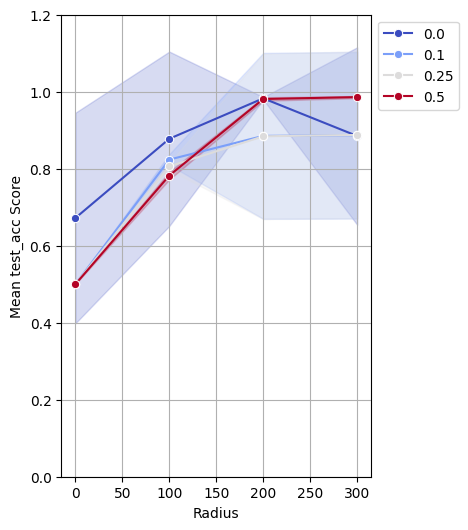

In [13]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class")

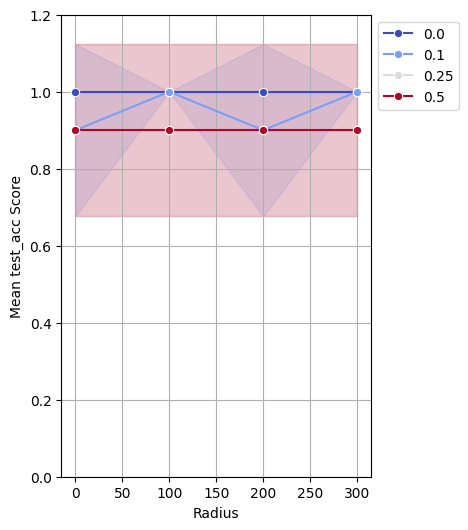

In [14]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class")

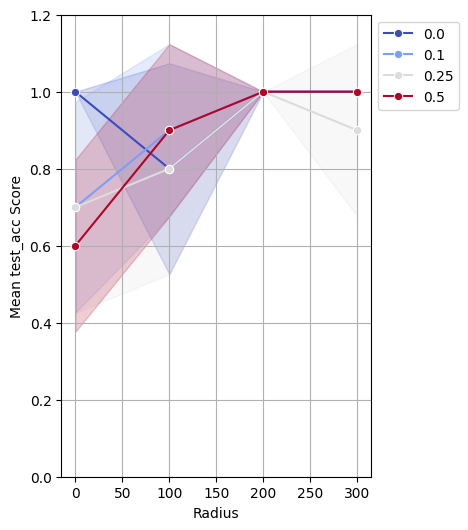

In [7]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class")

Index(['pct_mask_nodes', 'radius', 'mean_test_acc', 'std_test_acc',
       'mean_test_f1_class_0', 'std_test_f1_class_0', 'mean_test_f1_class_1',
       'std_test_f1_class_1'],
      dtype='object')


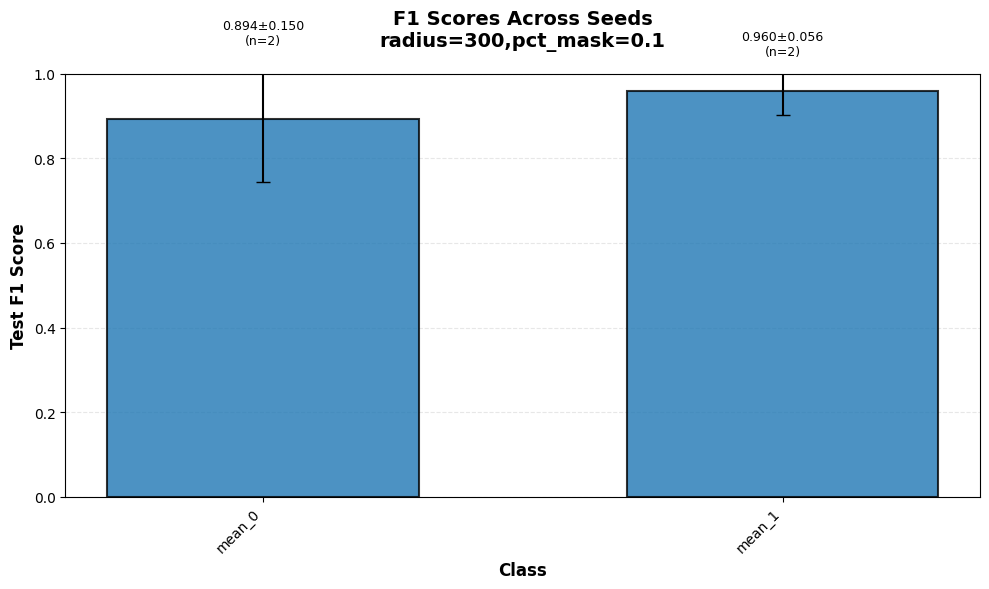

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_f1_across_seeds(dataframes, radius, pct_mask_nodes, 
                         figsize=(10, 6), title=None):
    """
    Plot mean and standard deviation of per-class F1 scores across seeds.
    
    Parameters:
    -----------
    dataframes : list of pd.DataFrame
        List of dataframes with the same columns
    radius : float or int
        Radius value to filter by
    decoder_type : str
        Decoder type to filter by
    pct_mask_nodes : float or int
        Percentage of masked nodes to filter by
    figsize : tuple, optional
        Figure size (width, height)
    title : str, optional
        Custom plot title
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    stats_df : pd.DataFrame
        DataFrame with mean and std for each class
    """
    
    # Concatenate all dataframes
    df_combined = pd.concat(dataframes, ignore_index=True)
    
    # Filter by specified parameters
    df_filtered = df_combined[
        (df_combined['radius'] == radius) &
        (df_combined['pct_mask_nodes'] == pct_mask_nodes)
    ]
    
    if df_filtered.empty:
        raise ValueError(f"No data found for radius={radius}, pct_mask_nodes={pct_mask_nodes}")

    print(df_filtered.columns)
    
    # Identify F1 score columns (columns starting with 'test_f1/class_')
    f1_cols = [col for col in df_filtered.columns if col.startswith('mean_test_f1_class')]
    
    if not f1_cols:
        raise ValueError("No 'test_f1/class_*' columns found in the dataframe")
    
    # Extract class names
    class_names = [col.replace('test_f1_class_', '') for col in f1_cols]
    
    # Calculate mean and std for each class across seeds
    stats = []
    for col, class_name in zip(f1_cols, class_names):
        mean_val = df_filtered[col].mean()
        std_val = df_filtered[col].std()
        n_seeds = df_filtered[col].count()
        stats.append({
            'class': class_name,
            'mean': mean_val,
            'std': std_val,
            'n_seeds': n_seeds
        })
    
    stats_df = pd.DataFrame(stats)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(class_names))
    width = 0.6
    
    # Plot bars with error bars
    bars = ax.bar(x, stats_df['mean'], width, 
                   yerr=stats_df['std'], 
                   capsize=5,
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1.5)
    
    # Customize the plot
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test F1 Score', fontsize=12, fontweight='bold')
    
    if title is None:
        title = (f'F1 Scores Across Seeds\n'
                f'radius={radius},'
                f'pct_mask={pct_mask_nodes}')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Set y-axis limits
    ax.set_ylim([0, 1.0])
    
    # Add value labels on top of bars
    for i, (bar, row) in enumerate(zip(bars, stats_df.itertuples())):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + row.std + 0.02,
                f'{row.mean:.3f}±{row.std:.3f}\n(n={int(row.n_seeds)})',
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    return fig, ax, stats_df


# Example usage:
df_list = [GNN_wandb.get_mean_and_std(), PCATrans_wandb.get_mean_and_std()]  # Your list of dataframes
fig, ax, stats = plot_f1_across_seeds(
    df_list, 
    radius=300, 
    pct_mask_nodes=0.1
)
plt.show()
#
# Print statistics:
# print(stats)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be fi

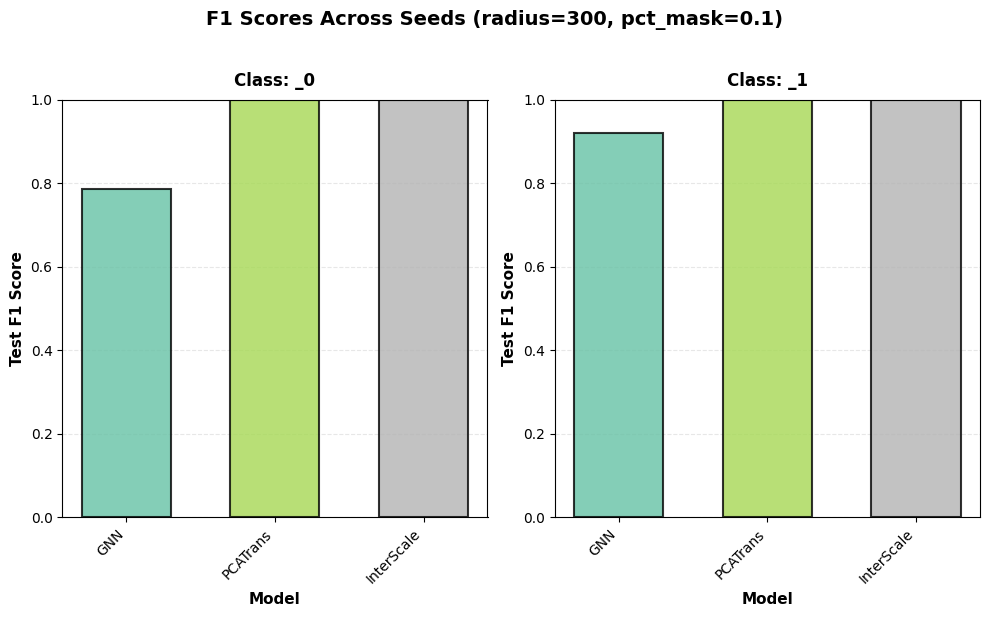

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_f1_across_seeds(dataframes, radius, pct_mask_nodes, 
                         dataframe_labels=None, figsize=None, title=None):
    """
    Plot mean and standard deviation of per-class F1 scores across seeds.
    Creates one subplot per class, with one bar per dataframe.
    
    Parameters:
    -----------
    dataframes : list of pd.DataFrame
        List of dataframes with the same columns
    radius : float or int
        Radius value to filter by
    pct_mask_nodes : float or int
        Percentage of masked nodes to filter by
    dataframe_labels : list of str, optional
        Labels for each dataframe (e.g., ['GNN', 'PCATrans', 'InterScale'])
        If None, will use 'DF1', 'DF2', etc.
    figsize : tuple, optional
        Figure size (width, height). If None, auto-calculated
    title : str, optional
        Custom overall plot title
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    stats_df : pd.DataFrame
        DataFrame with mean and std for each class and dataframe
    """
    
    # Set default labels if not provided
    if dataframe_labels is None:
        dataframe_labels = [f'DF{i+1}' for i in range(len(dataframes))]
    
    if len(dataframe_labels) != len(dataframes):
        raise ValueError("Number of labels must match number of dataframes")
    
    # Process each dataframe
    all_stats = []
    
    for df_idx, (df, df_label) in enumerate(zip(dataframes, dataframe_labels)):
        # Filter by specified parameters
        df_filtered = df[
            (df['radius'] == radius) &
            (df['pct_mask_nodes'] == pct_mask_nodes)
        ]
        
        if df_filtered.empty:
            print(f"Warning: No data found for {df_label} with radius={radius}, pct_mask_nodes={pct_mask_nodes}")
            continue
        
        # Identify F1 score columns
        f1_cols = [col for col in df_filtered.columns if col.startswith('mean_test_f1_class')]
        
        if not f1_cols:
            raise ValueError(f"No 'test_f1/class_*' columns found in {df_label}")
        
        # Calculate stats for each class
        for col in f1_cols:
            class_name = col.replace('mean_test_f1_class', '')
            mean_val = df_filtered[col].mean()
            std_val = df_filtered[col].std()
            n_seeds = df_filtered[col].count()
            
            all_stats.append({
                'dataframe': df_label,
                'class': class_name,
                'mean': mean_val,
                'std': std_val,
                'n_seeds': n_seeds
            })
    
    stats_df = pd.DataFrame(all_stats)
    
    if stats_df.empty:
        raise ValueError("No data found matching the specified parameters")
    
    # Get unique classes
    classes = stats_df['class'].unique()
    n_classes = len(classes)
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        figsize = (5 * n_classes, 6)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_classes, figsize=figsize)
    
    # Handle single class case
    if n_classes == 1:
        axes = [axes]
    
    # Color palette for dataframes
    colors = plt.cm.Set2(np.linspace(0, 1, len(dataframe_labels)))
    
    # Plot each class in its own subplot
    for ax, class_name in zip(axes, classes):
        class_data = stats_df[stats_df['class'] == class_name]
        
        x = np.arange(len(class_data))
        width = 0.6
        
        # Plot bars with error bars
        bars = ax.bar(x, class_data['mean'], width,
                      yerr=class_data['std'],
                      capsize=5,
                      alpha=0.8,
                      edgecolor='black',
                      linewidth=1.5,
                      color=[colors[dataframe_labels.index(label)] 
                             for label in class_data['dataframe']])
        
        # Customize subplot
        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Test F1 Score', fontsize=11, fontweight='bold')
        ax.set_title(f'Class: {class_name}', fontsize=12, fontweight='bold', pad=10)
        
        ax.set_xticks(x)
        ax.set_xticklabels(class_data['dataframe'], rotation=45, ha='right')
        
        # Add grid
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Set y-axis limits
        ax.set_ylim([0, 1.0])
        
        # Add value labels on bars
        for i, (bar, row) in enumerate(zip(bars, class_data.itertuples())):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + row.std + 0.02,
                    f'{row.mean:.3f}\n±{row.std:.3f}',
                    ha='center', va='bottom', fontsize=9)
    
    # Overall title
    if title is None:
        title = f'F1 Scores Across Seeds (radius={radius}, pct_mask={pct_mask_nodes})'
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    return fig, axes, stats_df


# Example usage:
df_list = [GNN_wandb.get_mean_and_std(), PCATrans_wandb.get_mean_and_std(), InterScale_wandb.get_mean_and_std()]  # Your list of dataframes
labels = ['GNN', 'PCATrans', 'InterScale']

fig, axes, stats = plot_f1_across_seeds(
    dataframes=df_list,
    radius=300,
    pct_mask_nodes=0.1,
    dataframe_labels=labels
)
# plt.show()
#
# Print statistics:
# print(stats)

/localscratch/francesca.drummer/ipykernel_1710352/2721575626.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/localscratch/francesca.drummer/ipykernel_1710352/2721575626.py:178: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


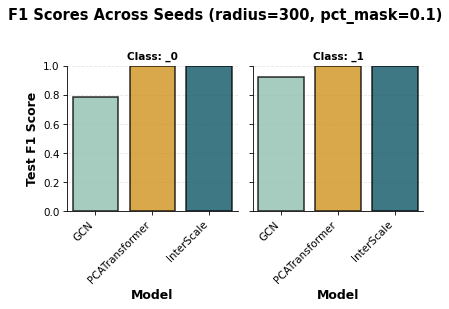

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import os

def plot_f1_across_seeds(dataframes, radius, pct_mask_nodes, 
                         dataframe_labels=None, config_path='config.yml',
                         height=4, aspect=0.7):
    """
    Plot mean and standard deviation of per-class F1 scores across seeds.
    Uses seaborn catplot with one facet per class and one bar per dataframe.
    
    Parameters:
    -----------
    dataframes : list of pd.DataFrame
        List of dataframes with the same columns
    radius : float or int
        Radius value to filter by
    pct_mask_nodes : float or int
        Percentage of masked nodes to filter by
    dataframe_labels : list of str, optional
        Labels for each dataframe (e.g., ['GCN', 'PCATransformer', 'InterScale'])
        If None, will use 'DF1', 'DF2', etc.
    config_path : str, optional
        Path to config.yml file (default: 'config.yml')
    height : float, optional
        Height of each facet in inches (default: 4)
    aspect : float, optional
        Aspect ratio of each facet (default: 0.7)
    
    Returns:
    --------
    g : seaborn FacetGrid
        The catplot object
    stats_df : pd.DataFrame
        DataFrame with mean and std for each class and dataframe
    plot_data : pd.DataFrame
        Long-form data used for plotting
    """
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    # Load config
    with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
        config = yaml.safe_load(f)
    
    general_config = config['plot_configs']['general']
    model_palette = config['palettes']['Models']
    
    # Apply general plot settings
    plt.rcParams['figure.dpi'] = general_config['dpi']
    plt.rcParams['savefig.dpi'] = general_config['dpi_save']
    plt.rcParams['font.family'] = general_config['font_family']
    plt.rcParams['font.size'] = 10
    
    # Set default labels if not provided
    if dataframe_labels is None:
        dataframe_labels = [f'DF{i+1}' for i in range(len(dataframes))]
    
    if len(dataframe_labels) != len(dataframes):
        raise ValueError("Number of labels must match number of dataframes")
    
    # Process each dataframe and collect all data
    all_data = []
    
    for df_idx, (df, df_label) in enumerate(zip(dataframes, dataframe_labels)):
        # Filter by specified parameters
        df_filtered = df[
            (df['radius'] == radius) &
            (df['pct_mask_nodes'] == pct_mask_nodes)
        ].copy()
        
        if df_filtered.empty:
            print(f"Warning: No data found for {df_label} with radius={radius}, pct_mask_nodes={pct_mask_nodes}")
            continue
        
        # Identify F1 score columns
        f1_cols = [col for col in df_filtered.columns if col.startswith('mean_test_f1_class')]
        
        if not f1_cols:
            raise ValueError(f"No 'test_f1/class_*' columns found in {df_label}")
        
        # Add dataframe label
        df_filtered['model'] = df_label
        
        # Collect the data
        all_data.append(df_filtered)
    
    if not all_data:
        raise ValueError("No data found matching the specified parameters")
    
    # Combine all dataframes
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Identify F1 columns
    f1_cols = [col for col in combined_df.columns if col.startswith('mean_test_f1_class')]
    
    # Reshape to long format for seaborn
    plot_data = combined_df.melt(
        id_vars=['model'],
        value_vars=f1_cols,
        var_name='class',
        value_name='f1_score'
    )
    
    # Clean up class names
    plot_data['class'] = plot_data['class'].str.replace('mean_test_f1_class', '')
    
    # Calculate statistics for reference
    stats_df = plot_data.groupby(['model', 'class'])['f1_score'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count')
    ]).reset_index()
    
    # Create color palette based on model names
    # Use palette from config if model name exists, otherwise use default colors
    palette = []
    for label in dataframe_labels:
        if label in model_palette:
            palette.append(model_palette[label])
        else:
            # Use seaborn default if model not in config
            palette.append(None)
    
    # If all models are in config, use the palette; otherwise let seaborn handle it
    use_palette = palette if all(c is not None for c in palette) else None
    
    # Create the catplot
    g = sns.catplot(
        data=plot_data,
        kind="bar",
        x="model",
        y="f1_score",
        col="class",
        height=height,
        aspect=aspect,
        errorbar="sd",  # Standard deviation error bars
        capsize=0.1,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.8,
        palette=use_palette
    )
    
    # Customize the plot with config settings
    g.set_axis_labels(
        "Model", 
        "Test F1 Score", 
        fontsize=general_config['legend_fontsize'],
        fontweight=general_config['legend_fontweight']
    )
    g.set_titles(
        "Class: {col_name}", 
        fontsize=general_config['title_fontsize'],
        fontweight=general_config['title_fontweight']
    )
    
    # Set y-axis limits and grid
    for ax in g.axes.flat:
        ax.set_ylim([0, 1.0])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # Rotate x-axis labels if needed
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    # Overall title
    g.fig.suptitle(
        f'F1 Scores Across Seeds (radius={radius}, pct_mask={pct_mask_nodes})',
        fontsize=general_config['title_fontsize'],
        fontweight=general_config['title_fontweight'],
        y=1.02
    )
    
    plt.tight_layout()
    
    return g, stats_df, plot_data


# Example usage:
# df_list = [df_gcn, df_pcatrans, df_interscale]
labels = ['GCN', 'PCATransformer', 'InterScale']

g, stats, plot_data = plot_f1_across_seeds(
    dataframes=df_list,
    radius=300,
    pct_mask_nodes=0.1,
    dataframe_labels=labels,
    config_path='config.yml',
    height=4,
    aspect=0.7
)
plt.show()
#
# # Save with high DPI
g.savefig('f1_scores.png', dpi=300, bbox_inches='tight')
#
# # Print statistics:
# print(stats)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import os

def plot_f1_across_seeds(wandb_evaluations, radius, pct_mask_nodes, 
                         config_path='config.yml', height=4, aspect=0.7):
    """
    Plot mean and standard deviation of per-class F1 scores across seeds.
    Uses seaborn catplot with one facet per class and one bar per model.
    
    Parameters:
    -----------
    wandb_evaluations : list of Wandb_evaluation
        List of Wandb_evaluation instances, one per model
    radius : float or int
        Radius value to filter by
    pct_mask_nodes : float or int
        Percentage of masked nodes to filter by
    config_path : str, optional
        Path to config.yml file (default: 'config.yml')
    height : float, optional
        Height of each facet in inches (default: 4)
    aspect : float, optional
        Aspect ratio of each facet (default: 0.7)
    
    Returns:
    --------
    g : seaborn FacetGrid
        The catplot object
    stats_df : pd.DataFrame
        DataFrame with mean and std for each class and model
    plot_data : pd.DataFrame
        Long-form data used for plotting
    """
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    # Load config
    with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
        config = yaml.safe_load(f)
    
    general_config = config['plot_configs']['general']
    model_palette = config['palettes']['Models']
    
    # Apply general plot settings
    plt.rcParams['figure.dpi'] = general_config['dpi']
    plt.rcParams['savefig.dpi'] = general_config['dpi_save']
    plt.rcParams['font.family'] = general_config['font_family']
    plt.rcParams['font.size'] = 10
    
    # Process each Wandb_evaluation instance
    all_data = []
    model_names = []
    
    for wandb_eval in wandb_evaluations:
        model_name = wandb_eval.model
        df = wandb_eval.df
        classes = wandb_eval.classes
        
        model_names.append(model_name)
        
        # Filter by specified parameters
        df_filtered = df[
            (df['radius'] == radius) &
            (df['pct_mask_nodes'] == pct_mask_nodes)
        ].copy()
        
        if df_filtered.empty:
            print(f"Warning: No data found for {model_name} with radius={radius}, pct_mask_nodes={pct_mask_nodes}")
            continue
        
        # Identify F1 score columns
        f1_cols = [col for col in df_filtered.columns if col.startswith('test_f1/class_')]
        
        if not f1_cols:
            raise ValueError(f"No 'test_f1/class_*' columns found in {model_name}")
        
        # Add model label
        df_filtered['model'] = model_name
        
        # Collect the data
        all_data.append(df_filtered)
    
    if not all_data:
        raise ValueError("No data found matching the specified parameters")
    
    # Combine all dataframes
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Identify F1 columns
    f1_cols = [col for col in combined_df.columns if col.startswith('test_f1/class_')]
    
    # Reshape to long format for seaborn
    plot_data = combined_df.melt(
        id_vars=['model'],
        value_vars=f1_cols,
        var_name='class',
        value_name='f1_score'
    )
    
    # Clean up class names
    plot_data['class'] = plot_data['class'].str.replace('test_f1/class_', '')
    
    # Calculate statistics for reference
    stats_df = plot_data.groupby(['model', 'class'])['f1_score'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count')
    ]).reset_index()
    
    # Create color palette based on model names from config
    palette = []
    for model_name in model_names:
        if model_name in model_palette:
            palette.append(model_palette[model_name])
        else:
            print(f"Warning: Model '{model_name}' not found in config palette. Using default color.")
            palette.append(None)
    
    # If all models are in config, use the palette; otherwise let seaborn handle it
    use_palette = palette if all(c is not None for c in palette) else None
    
    # Create the catplot
    g = sns.catplot(
        data=plot_data,
        kind="bar",
        x="model",
        y="f1_score",
        col="class",
        height=height,
        aspect=aspect,
        errorbar="sd",  # Standard deviation error bars
        capsize=0.1,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.8,
        palette=use_palette
    )
    
    # Customize the plot with config settings
    g.set_axis_labels(
        "Model", 
        "Test F1 Score", 
        fontsize=general_config['legend_fontsize'],
        fontweight=general_config['legend_fontweight']
    )
    g.set_titles(
        "Class: {col_name}", 
        fontsize=general_config['title_fontsize'],
        fontweight=general_config['title_fontweight']
    )
    
    # Set y-axis limits and grid
    for ax in g.axes.flat:
        ax.set_ylim([0, 1.0])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # Rotate x-axis labels if needed
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    # Overall title
    g.fig.suptitle(
        f'F1 Scores Across Seeds (radius={radius}, pct_mask={pct_mask_nodes})',
        fontsize=general_config['title_fontsize'],
        fontweight=general_config['title_fontweight'],
        y=1.02
    )
    
    plt.tight_layout()
    
    return g, stats_df, plot_data


# # Plot
wandb_evals = [GNN_wandb, PCATrans_wandb]  # Your list of dataframes

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=300,
    pct_mask_nodes=0.1,
    config_path='config.yml',
    height=4,
    aspect=0.7
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)